# Heston — Method Comparison

| Method | Trainer | Notes |
|---|---|---|
| **Delta LSMC** | — | Regression-based delta baseline |
| **Delta CF** | — | Exact Heston delta (slow) |
| **DH** | DeepHedging | Plain MLP |
| **DH-PAF** | DeepHedging | PAF embedding |
| **DH-PnL** | DeepHedging | MLP + running P&L feature |
| **DH-PAF-PnL** | DeepHedging | PAF + P&L |
| **DH-SAC** | SAC | Entropy regularisation |
| **DH-Deviation** | Deviation | Net predicts δ − δ_BSM, Adam |
| **DH-Deviation-KFAC** | Deviation | Same, K-FAC natural-gradient optimiser |
| **DH-Deviation-Muon** | Deviation | Same, Muon (Newton-Schulz orthogonalised updates) |

## 0. Setup

In [1]:
import os
import time

import numpy as np
import torch
import matplotlib.pyplot as plt

from src.samplers      import HestonSampler
from src.metrics       import SoftMin
from src.backtest      import torch_backtest
from src.models        import ModelConfig
from src.trainers      import (TrainerConfig, DeepHedgingTrainer, SACTrainer,
                               DeviationTrainer)
from src.deltas        import (LSMCDeltaHedger, HestonCFDeltaHedger,
                               HestonMVDeltaHedger)
from src.logging_utils import save_log

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)


Device: cuda


## 1. Parameters

In [2]:
# ── market ────────────────────────────────────────────────
S0    = 100.0
v0    = 0.04
r     = 0.01
kappa = 2.0
theta = 0.04
xi    = 0.1
rho   = -0.7
T     = 1.0
N     = 30
K     = 100.0
cost  = 0.0
a     = 1.0

# ── training ──────────────────────────────────────────────
M_train  = 3_000
M_val    = 5_000   # validation paths (used for early stopping & best model)
M_test   = 5_000   # held-out test paths (evaluated once at the end)
n_epochs = 10_000
log_every           = 200
early_stop_patience = 100  # val checks without improvement → stop
lr                  = 1e-3

RESULTS_DIR = 'results_heston_cf_mv_copy3_cost0'
os.makedirs(RESULTS_DIR, exist_ok=True)

# ── paths ─────────────────────────────────────────────────
sampler = HestonSampler(
    S0=S0, v0=v0, r=r, kappa=kappa,
    theta=theta, xi=xi, rho=rho, T=T, N=N
)

np.random.seed(42)
paths_val    = sampler.sample(M_val)
paths_test   = sampler.sample(M_test)
paths_val_t  = torch.tensor(paths_val,  dtype=torch.float32, device=DEVICE)
paths_test_t = torch.tensor(paths_test, dtype=torch.float32, device=DEVICE)

results = {}  # name -> {pnl, fees, log}

## 2. Helpers

In [3]:
def softmin_np(pnl: np.ndarray, a: float = a) -> float:
    return float(np.log(np.exp(-a * pnl).mean()) / a)

def sync_device():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

def _rectangular_log(rows: list[dict]) -> list[dict]:
    keys = []
    for row in rows:
        for key in row.keys():
            if key not in keys:
                keys.append(key)
    return [{key: row.get(key, float('nan')) for key in keys} for row in rows]

def record(name: str, pnl: np.ndarray, fees: np.ndarray,
           log: list | None = None, elapsed: float | None = None):
    log = [] if log is None else log
    results[name] = {'pnl': pnl, 'fees': fees, 'log': log, 'elapsed': elapsed}
    elapsed_msg = '' if elapsed is None else f"  elapsed={elapsed:>7.2f}s"
    print(f"  {name:<22}  SoftMin={softmin_np(pnl):>8.4f}  "
          f"mean={pnl.mean():>7.4f}  std={pnl.std():>6.4f}  "
          f"fees={fees.mean():>7.4f}" + elapsed_msg)

    test_summary = {
        "test_softmin": softmin_np(pnl),
        "mean_pnl": float(pnl.mean()),
        "std_pnl": float(pnl.std()),
        "fees_mean": float(fees.mean()),
        "elapsed": 0.0 if elapsed is None else float(elapsed),
    }
    if not log:
        summary = [{"epoch": 0, "val_loss": test_summary["test_softmin"],
                    **test_summary}]
    else:
        summary = [dict(e) for e in log]
        final = {"epoch": summary[-1].get("epoch", 0),
                 "val_loss": summary[-1].get("val_loss", float('nan')),
                 **test_summary}
        summary.append(final)
        summary = _rectangular_log(summary)
    save_log(summary, os.path.join(RESULTS_DIR, name.replace(' ', '_')))

def run_trainer(trainer, name: str):
    t0 = time.perf_counter()
    log = trainer.fit()
    pnl, fees = trainer.eval_on_test()
    sync_device()
    record(name, pnl, fees, log, elapsed=time.perf_counter() - t0)

def base_cfg(**overrides) -> TrainerConfig:
    """TrainerConfig with shared defaults."""
    defaults = dict(
        n_epochs=n_epochs, M_train=M_train,
        log_every=log_every,
        early_stop_patience=early_stop_patience,
        lr=lr,
    )
    return TrainerConfig(**{**defaults, **overrides})


def make_trainer(TrainerClass, cfg, **kwargs):
    return TrainerClass(
        cfg=cfg,
        sampler=sampler,
        paths_val_t=paths_val_t,
        paths_test_t=paths_test_t,
        device=DEVICE,
        risk_aversion=a,
        K=K,
        cost=cost,
        **kwargs
    )


print('Helpers ready.')


Helpers ready.


## 3. Delta LSMC baseline

In [4]:
lsmc = LSMCDeltaHedger(K=K, cost=cost)
t0 = time.perf_counter()
lsmc.fit(sampler.sample(10_000))
pnl, fees = lsmc.backtest(paths_test)
record('Delta LSMC', pnl, fees, elapsed=time.perf_counter() - t0)


  Delta LSMC              SoftMin=  9.7463  mean=-7.8782  std=2.1273  fees= 0.0000  elapsed=   0.07s


## 4. Delta CF baseline

In [5]:
M_test_cf = M_test
CF_N_QUAD = 512
CF_REF_PATHS = 20

cf = HestonCFDeltaHedger(
    K=K, r=r, kappa=kappa, theta=theta,
    xi=xi, rho=rho, T=T, N=N, cost=cost,
    n_quad=CF_N_QUAD, device=DEVICE, batch_size=8192,
)

# Validate the new torch/autograd delta against the old scipy finite-difference path.
S_check = np.array([80., 90., 100., 110., 120.])
v_check = np.array([0.02, 0.04, 0.04, 0.06, 0.08])
tau_check = 0.7
fast_check = cf._delta(S_check, v_check, tau_check)
ref_check = cf._delta_scipy(S_check, v_check, tau_check)
print(f"CF delta check: max_abs_diff={np.max(np.abs(fast_check - ref_check)):.3e} "
      f"with n_quad={CF_N_QUAD}")

# Time a small old-scipy slice and extrapolate to the full notebook baseline size.
cash_ref = np.zeros(CF_REF_PATHS)
delta_prev_ref = np.zeros(CF_REF_PATHS)
fees_ref = np.zeros(CF_REF_PATHS)
t0 = time.perf_counter()
for t in range(N):
    tau = T - t * T / N
    delta_t = cf._delta_scipy(paths_test[:CF_REF_PATHS, t, 0],
                              paths_test[:CF_REF_PATHS, t, 1], tau)
    d_delta = delta_t - delta_prev_ref
    cash_ref -= d_delta * paths_test[:CF_REF_PATHS, t, 0]
    fee_t = cost * np.abs(d_delta) * paths_test[:CF_REF_PATHS, t, 0]
    cash_ref -= fee_t
    fees_ref += fee_t
    delta_prev_ref = delta_t
cash_ref += delta_prev_ref * paths_test[:CF_REF_PATHS, -1, 0]
pnl_ref = cash_ref - np.clip(paths_test[:CF_REF_PATHS, -1, 0] - K, 0, None)
old_elapsed = time.perf_counter() - t0
print(f"Old scipy CF: {old_elapsed:.2f}s for {CF_REF_PATHS} paths; "
      f"linear extrapolation to {M_test_cf} paths = {old_elapsed * M_test_cf / CF_REF_PATHS:.1f}s")

# Full fast CF baseline.
t0 = time.perf_counter()
pnl, fees = cf.backtest(paths_test[:M_test_cf], verbose=False)
sync_device()
new_elapsed = time.perf_counter() - t0
record('Delta CF', pnl, fees, elapsed=new_elapsed)
print(f"Fast CF speedup vs extrapolated scipy: "
      f"{(old_elapsed * M_test_cf / CF_REF_PATHS) / new_elapsed:,.0f}x")


CF delta check: max_abs_diff=1.888e-06 with n_quad=512


Old scipy CF: 5.73s for 20 paths; linear extrapolation to 5000 paths = 1433.1s
  Delta CF                SoftMin=  9.2715  mean=-7.8989  std=1.4779  fees= 0.0000  elapsed=   0.18s
Fast CF speedup vs extrapolated scipy: 8,079x


## 4b. Delta MV / Bartlett baseline

In [6]:
mv = HestonMVDeltaHedger(
    K=K, r=r, kappa=kappa, theta=theta,
    xi=xi, rho=rho, T=T, N=N, cost=cost,
    n_quad=CF_N_QUAD, device=DEVICE, batch_size=8192,
)

t0 = time.perf_counter()
pnl, fees = mv.backtest(paths_test[:M_test_cf], verbose=False)
sync_device()
record('Delta MV', pnl, fees, elapsed=time.perf_counter() - t0)


  Delta MV                SoftMin=  9.1966  mean=-7.9149  std=1.3408  fees= 0.0000  elapsed=   0.18s


## 5. DH — plain MLP

In [7]:
run_trainer(
    make_trainer(DeepHedgingTrainer,
                 base_cfg(model=ModelConfig(arch='mlp', hidden_dims=(64, 64)))),
    'DH'
)

Trainable parameters: 4,545


  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 1/10000 [00:00<45:18,  3.68it/s]

  0%|          | 3/10000 [00:00<19:02,  8.75it/s]

  0%|          | 5/10000 [00:00<14:42, 11.32it/s]

...

100%|█████████▉| 9996/10000 [10:21<00:00, 18.05it/s]

100%|█████████▉| 9998/10000 [10:21<00:00, 17.63it/s]

100%|██████████| 10000/10000 [10:22<00:00, 17.28it/s]

100%|██████████| 10000/10000 [10:22<00:00, 16.07it/s]

  DH                      SoftMin= 10.0053  mean=-7.8971  std=2.4536  fees= 0.0000  elapsed= 622.14s


## 6. DH-PAF

In [8]:
run_trainer(
    make_trainer(DeepHedgingTrainer,
                 base_cfg(model=ModelConfig(arch='paf'))),
    'DH-PAF'
)

Trainable parameters: 4,289


  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 2/10000 [00:00<13:06, 12.71it/s]

  0%|          | 4/10000 [00:00<12:26, 13.38it/s]

  0%|          | 6/10000 [00:00<12:06, 13.76it/s]

...

100%|█████████▉| 9996/10000 [12:07<00:00, 13.46it/s]

100%|█████████▉| 9998/10000 [12:07<00:00, 13.50it/s]

100%|██████████| 10000/10000 [12:07<00:00, 13.09it/s]

100%|██████████| 10000/10000 [12:07<00:00, 13.74it/s]

  DH-PAF                  SoftMin=  9.0135  mean=-7.9264  std=1.5208  fees= 0.0000  elapsed= 727.93s


## 7. DH-PnL

In [9]:
run_trainer(
    make_trainer(DeepHedgingTrainer,
                 base_cfg(model=ModelConfig(arch='mlp', hidden_dims=(64, 64)), use_pnl=True)),
    'DH-PnL'
)

Trainable parameters: 4,609


  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 2/10000 [00:00<11:34, 14.40it/s]

  0%|          | 4/10000 [00:00<11:53, 14.02it/s]

  0%|          | 6/10000 [00:00<11:34, 14.40it/s]

...

100%|█████████▉| 9996/10000 [11:07<00:00, 14.71it/s]

100%|█████████▉| 9998/10000 [11:07<00:00, 14.80it/s]

100%|██████████| 10000/10000 [11:07<00:00, 14.50it/s]

100%|██████████| 10000/10000 [11:07<00:00, 14.97it/s]

  DH-PnL                  SoftMin=  9.7361  mean=-7.9077  std=2.1311  fees= 0.0000  elapsed= 667.98s


## 8. DH-PAF-PnL

In [10]:
run_trainer(
    make_trainer(DeepHedgingTrainer,
                 base_cfg(model=ModelConfig(arch='paf'), use_pnl=True)),
    'DH-PAF-PnL'
)

Trainable parameters: 4,305


  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 2/10000 [00:00<12:34, 13.26it/s]

  0%|          | 4/10000 [00:00<12:37, 13.20it/s]

  0%|          | 6/10000 [00:00<12:40, 13.15it/s]

...

100%|█████████▉| 9996/10000 [12:37<00:00, 12.96it/s]

100%|█████████▉| 9998/10000 [12:37<00:00, 13.07it/s]

100%|██████████| 10000/10000 [12:37<00:00, 12.71it/s]

100%|██████████| 10000/10000 [12:37<00:00, 13.20it/s]

  DH-PAF-PnL              SoftMin= 23.6153  mean=-7.9305  std=5.4934  fees= 0.0000  elapsed= 757.64s


## 9. DH-SAC

In [11]:
run_trainer(
    make_trainer(SACTrainer,
                 base_cfg(model=ModelConfig(arch='paf'),
                          beta_start=0.05, beta_end=0.001)),
    'DH-SAC'
)

Trainable parameters: 4,289


  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 2/10000 [00:00<12:56, 12.88it/s]

  0%|          | 4/10000 [00:00<13:05, 12.73it/s]

  0%|          | 6/10000 [00:00<12:59, 12.82it/s]

...

100%|█████████▉| 9996/10000 [12:18<00:00, 12.99it/s]

100%|█████████▉| 9998/10000 [12:18<00:00, 12.98it/s]

100%|██████████| 10000/10000 [12:18<00:00, 12.80it/s]

100%|██████████| 10000/10000 [12:18<00:00, 13.54it/s]

  DH-SAC                  SoftMin=  8.9815  mean=-7.9264  std=1.5302  fees= 0.0000  elapsed= 738.79s


## 10. DH-PAF-PnL Pretrain Without PnL

In [12]:
run_trainer(
    make_trainer(DeepHedgingTrainer,
                 base_cfg(model=ModelConfig(arch='paf'), use_pnl=True, pnl_start_epoch = 2000)),
    'DH-PAF-PnL-Pretrain'
)

Trainable parameters: 4,305


  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 2/10000 [00:00<11:48, 14.11it/s]

  0%|          | 4/10000 [00:00<12:48, 13.01it/s]

  0%|          | 6/10000 [00:00<12:39, 13.16it/s]

...

100%|█████████▉| 9996/10000 [12:31<00:00, 13.01it/s]

100%|█████████▉| 9998/10000 [12:32<00:00, 13.23it/s]

100%|██████████| 10000/10000 [12:32<00:00, 12.78it/s]

100%|██████████| 10000/10000 [12:32<00:00, 13.29it/s]

  DH-PAF-PnL-Pretrain     SoftMin= 48.4367  mean=-7.9500  std=8.0674  fees= 0.0000  elapsed= 752.20s


## 11. Delta PnL Deviation Runner

In [13]:

# Heston (sigma_const=None → берём sqrt(v_t))
run_trainer(
    DeviationTrainer(
        cfg          = base_cfg(model=ModelConfig(arch='paf',
                                                  zero_last_layer=True),
                                use_pnl=True),
        sampler      = sampler,
        paths_val_t  = paths_val_t,
        paths_test_t = paths_test_t,
        device       = DEVICE,
        risk_aversion = a, K = K, cost = cost,
        r            = r,
        sigma_const  = None,  # Heston mode
    ),
    'DH-Deviation'
)

Trainable parameters: 4,305


  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 2/10000 [00:00<14:03, 11.85it/s]

  0%|          | 4/10000 [00:00<14:14, 11.69it/s]

  0%|          | 6/10000 [00:00<13:51, 12.02it/s]

...

100%|█████████▉| 9996/10000 [13:45<00:00, 12.29it/s]

100%|█████████▉| 9998/10000 [13:45<00:00, 12.28it/s]

100%|██████████| 10000/10000 [13:45<00:00, 11.83it/s]

100%|██████████| 10000/10000 [13:45<00:00, 12.11it/s]

  DH-Deviation            SoftMin=  8.9572  mean=-7.9207  std=1.4548  fees= 0.0000  elapsed= 825.57s


## 12. DH-Deviation K-FAC

In [14]:
run_trainer(
    DeviationTrainer(
        cfg          = base_cfg(model=ModelConfig(arch='paf',
                                                  zero_last_layer=True),
                                use_pnl=True,
                                optimizer='kfac'),
        sampler      = sampler,
        paths_val_t  = paths_val_t,
        paths_test_t = paths_test_t,
        device       = DEVICE,
        risk_aversion = a, K = K, cost = cost,
        r            = r,
        sigma_const  = None,  # Heston mode
    ),
    'DH-Deviation-KFAC'
)

Trainable parameters: 4,305


  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 1/10000 [00:00<35:19,  4.72it/s]

  0%|          | 2/10000 [00:00<26:06,  6.38it/s]

  0%|          | 3/10000 [00:00<23:00,  7.24it/s]

...

100%|█████████▉| 9998/10000 [20:31<00:00,  8.23it/s]

100%|█████████▉| 9999/10000 [20:32<00:00,  8.24it/s]

100%|██████████| 10000/10000 [20:32<00:00,  7.73it/s]

100%|██████████| 10000/10000 [20:32<00:00,  8.12it/s]

  DH-Deviation-KFAC       SoftMin=  8.9613  mean=-7.9198  std=1.4370  fees= 0.0000  elapsed=1232.24s


## 13. DH-Deviation Muon

In [15]:
run_trainer(
    DeviationTrainer(
        cfg          = base_cfg(model=ModelConfig(arch='paf',
                                                  zero_last_layer=True),
                                use_pnl=True,
                                optimizer='muon',
                                lr=2e-2),
        sampler      = sampler,
        paths_val_t  = paths_val_t,
        paths_test_t = paths_test_t,
        device       = DEVICE,
        risk_aversion = a, K = K, cost = cost,
        r            = r,
        sigma_const  = None,  # Heston mode
    ),
    'DH-Deviation-Muon'
)

Trainable parameters: 4,305


  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 2/10000 [00:00<14:24, 11.56it/s]

  0%|          | 4/10000 [00:00<14:21, 11.61it/s]

  0%|          | 6/10000 [00:00<14:12, 11.72it/s]

...

100%|█████████▉| 9996/10000 [14:23<00:00, 11.62it/s]

100%|█████████▉| 9998/10000 [14:23<00:00, 11.57it/s]

100%|██████████| 10000/10000 [14:23<00:00, 11.00it/s]

100%|██████████| 10000/10000 [14:23<00:00, 11.58it/s]

  DH-Deviation-Muon       SoftMin=  9.0665  mean=-7.9133  std=1.4097  fees= 0.0000  elapsed= 863.47s


## 14. Summary table

In [16]:
import glob, json

def load_results(results_dir: str) -> dict:
    """Load all saved logs from results_dir into results dict."""
    loaded = {}
    for fpath in sorted(glob.glob(os.path.join(results_dir, '*.json'))):
        name = os.path.splitext(os.path.basename(fpath))[0].replace('_', ' ')
        with open(fpath) as f:
            log = json.load(f)
        # baseline записи имеют mean_pnl/std_pnl, восстанавливаем заглушку
        loaded[name] = {
            'pnl':  None,
            'fees': None,
            'log':  log,
        }
    return loaded


results = load_results(RESULTS_DIR)

In [17]:
print(f"\n{'Method':<24} {'SoftMin':>10} {'PnL mean':>10} {'PnL std':>9} {'Fees mean':>10} {'Elapsed':>10}")
print('-' * 84)
for name, res in results.items():
    log = res.get('log', [])
    if res['pnl'] is not None:
        pnl, fees = res['pnl'], res['fees']
        elapsed = res.get('elapsed')
        elapsed_s = 'n/a' if elapsed is None else f"{elapsed:.2f}s"
        print(f"{name:<24} {softmin_np(pnl):>10.4f} {pnl.mean():>10.4f} "
              f"{pnl.std():>9.4f} {fees.mean():>10.4f} {elapsed_s:>10}")
    elif log:
        last = log[-1]
        sm = last.get('test_softmin', last.get('val_loss', float('nan')))
        mean = last.get('mean_pnl', float('nan'))
        std = last.get('std_pnl', float('nan'))
        fees_mean = last.get('fees_mean', float('nan'))
        elapsed = last.get('elapsed', float('nan'))
        elapsed_s = 'n/a' if np.isnan(elapsed) else f"{elapsed:.2f}s"
        print(f"{name:<24} {sm:>10.4f} {mean:>10.4f} {std:>9.4f} "
              f"{fees_mean:>10.4f} {elapsed_s:>10}")



Method                      SoftMin   PnL mean   PnL std  Fees mean    Elapsed
------------------------------------------------------------------------------------
DH-Deviation-KFAC            8.9613    -7.9198    1.4370     0.0000   1232.24s
DH-Deviation-Muon            9.0665    -7.9133    1.4097     0.0000    863.47s
DH-Deviation                 8.9572    -7.9207    1.4548     0.0000    825.57s
DH-PAF-PnL-Pretrain         48.4367    -7.9500    8.0674     0.0000    752.20s
DH-PAF-PnL                  23.6153    -7.9305    5.4934     0.0000    757.64s
DH-PAF                       9.0135    -7.9264    1.5208     0.0000    727.93s
DH-PnL                       9.7361    -7.9077    2.1311     0.0000    667.98s
DH-SAC                       8.9815    -7.9264    1.5302     0.0000    738.79s
DH                          10.0053    -7.8971    2.4536     0.0000    622.14s
Delta CF                     9.2715    -7.8989    1.4779     0.0000      0.18s
Delta LSMC                   9.7463    -7.878

## 15. Learning curves

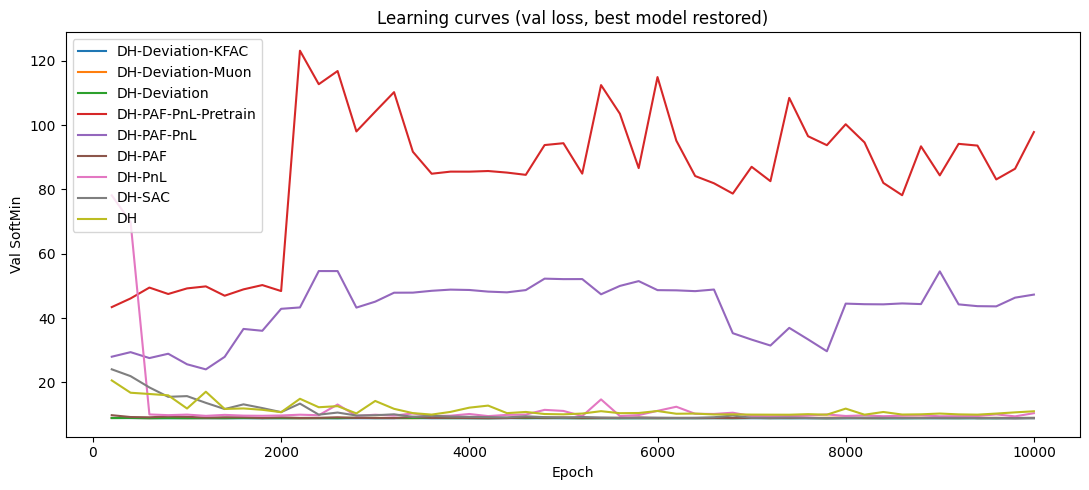

In [18]:
fig, ax = plt.subplots(figsize=(11, 5))
for name, res in results.items():
    log = res.get('log', [])
    # фильтруем baseline (одна запись с epoch=0)
    log = [e for e in log if e.get('epoch', 0) > 0]
    if not log:
        continue
    ax.plot([e['epoch']    for e in log],
            [e['val_loss'] for e in log], label=name)
ax.set_xlabel('Epoch')
ax.set_ylabel('Val SoftMin')
ax.set_title('Learning curves (val loss, best model restored)')
ax.legend()
plt.tight_layout()
plt.show()

DH-Deviation-KFAC [{'epoch': 200, 'val_loss': 8.960418701171875, 'elapsed': 24.54693302512169, 'test_softmin': nan, 'mean_pnl': nan, 'std_pnl': nan, 'fees_mean': nan}, {'epoch': 400, 'val_loss': 8.93248176574707, 'elapsed': 49.07125617610291, 'test_softmin': nan, 'mean_pnl': nan, 'std_pnl': nan, 'fees_mean': nan}, {'epoch': 600, 'val_loss': 8.905263900756836, 'elapsed': 73.70993014704436, 'test_softmin': nan, 'mean_pnl': nan, 'std_pnl': nan, 'fees_mean': nan}, {'epoch': 800, 'val_loss': 8.903157234191895, 'elapsed': 98.24978549173102, 'test_softmin': nan, 'mean_pnl': nan, 'std_pnl': nan, 'fees_mean': nan}, {'epoch': 1000, 'val_loss': 8.899396896362305, 'elapsed': 122.61170290783048, 'test_softmin': nan, 'mean_pnl': nan, 'std_pnl': nan, 'fees_mean': nan}, {'epoch': 1200, 'val_loss': 8.88530158996582, 'elapsed': 147.18312260881066, 'test_softmin': nan, 'mean_pnl': nan, 'std_pnl': nan, 'fees_mean': nan}, {'epoch': 1400, 'val_loss': 8.871383666992188, 'elapsed': 171.16864096699283, 'test_s

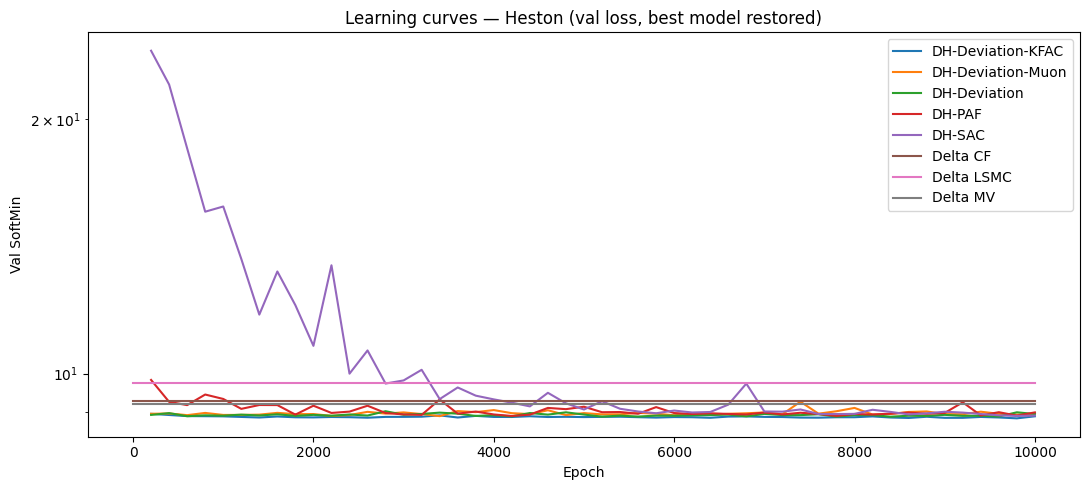

In [19]:
import copy

fig, ax = plt.subplots(figsize=(11, 5))
for name, res in results.items():
    if name in ['DH-PAF-PnL', 'DH-PAF-PnL-Pretrain', 'DH' , 'DH-PnL']:
        continue
    log = res.get('log', [])
    print(name, log)
    while log[-1]['epoch'] != 10000:
        tmp = copy.deepcopy(log[-1])
        tmp['epoch'] += 200
        log.append(tmp)

    if not log:
        continue
    ax.plot([e['epoch']    for e in log],
            [e['val_loss'] for e in log], label=name)
ax.set_xlabel('Epoch')
ax.set_ylabel('Val SoftMin')
ax.set_title('Learning curves — Heston (val loss, best model restored)')
ax.legend()
ax.set_yscale('log')
plt.tight_layout()
plt.show()

DH-Deviation-KFAC [{'epoch': 200, 'val_loss': 8.960418701171875, 'elapsed': 24.54693302512169, 'test_softmin': nan, 'mean_pnl': nan, 'std_pnl': nan, 'fees_mean': nan}, {'epoch': 400, 'val_loss': 8.93248176574707, 'elapsed': 49.07125617610291, 'test_softmin': nan, 'mean_pnl': nan, 'std_pnl': nan, 'fees_mean': nan}, {'epoch': 600, 'val_loss': 8.905263900756836, 'elapsed': 73.70993014704436, 'test_softmin': nan, 'mean_pnl': nan, 'std_pnl': nan, 'fees_mean': nan}, {'epoch': 800, 'val_loss': 8.903157234191895, 'elapsed': 98.24978549173102, 'test_softmin': nan, 'mean_pnl': nan, 'std_pnl': nan, 'fees_mean': nan}, {'epoch': 1000, 'val_loss': 8.899396896362305, 'elapsed': 122.61170290783048, 'test_softmin': nan, 'mean_pnl': nan, 'std_pnl': nan, 'fees_mean': nan}, {'epoch': 1200, 'val_loss': 8.88530158996582, 'elapsed': 147.18312260881066, 'test_softmin': nan, 'mean_pnl': nan, 'std_pnl': nan, 'fees_mean': nan}, {'epoch': 1400, 'val_loss': 8.871383666992188, 'elapsed': 171.16864096699283, 'test_s

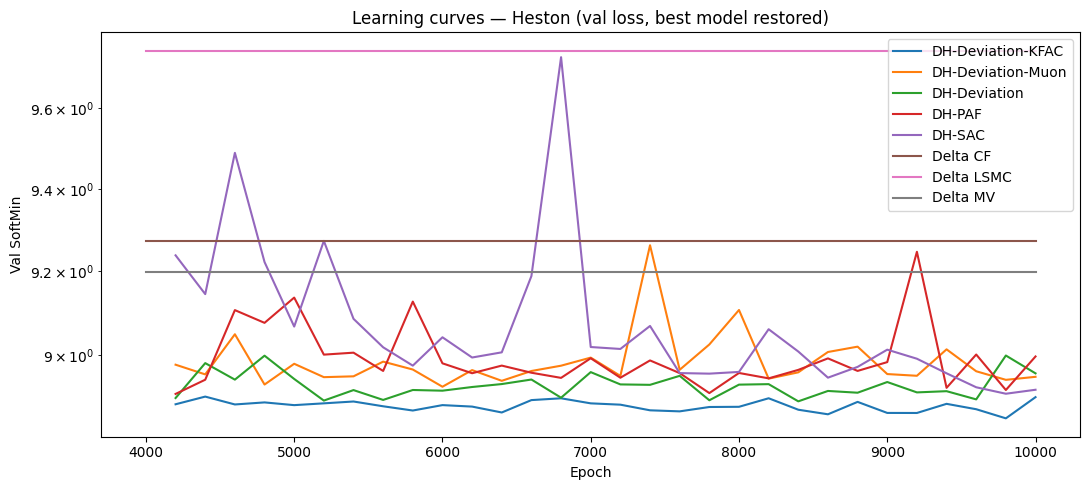

In [20]:
import copy

fig, ax = plt.subplots(figsize=(11, 5))
for name, res in results.items():
    if name in ['DH-PAF-PnL', 'DH-PAF-PnL-Pretrain', 'DH' , 'DH-PnL']:
        continue
    log = res.get('log', [])
    print(name, log)
    while log[-1]['epoch'] != 10000:
        tmp = copy.deepcopy(log[-1])
        tmp['epoch'] += 200
        log.append(tmp)

    log = log[20:]

    if not log:
        continue
    ax.plot([e['epoch']    for e in log],
            [e['val_loss'] for e in log], label=name)
ax.set_xlabel('Epoch')
ax.set_ylabel('Val SoftMin')
ax.set_title('Learning curves — Heston (val loss, best model restored)')
ax.legend()
ax.set_yscale('log')
plt.tight_layout()
plt.show()

## Results

- Deep Hedging (DH) > Delta Hedging with compatible speed on Heston
- DH > Delta Hedging on GBM (where Delta is optimal)
- PAF > No-PAF
- Adding PnL requires some tricks like predicting deviation from delta. Perhaps using true Heston Delta instead of GBM proxy would lead to better result but would require to train a full NN to predict delta.
- SAC gives improvement but they feel random unlike in DH-deviation (see plot above)
- Other improvements like K-FAC were not yet considered


---


- Overall this work is a part of my GQW and overall what I did there is more like an article and less of "article implementation", but I found no real "other RL algorithms" to compete with MCPG here, if something is worse than DH - I would just skip it.

1. Вам необходимо выбрать и реализовать алгоритм, предложенный в статье на ваш выбор, и провести ряд экспериментов из этого исследования. Учитывая ограничения на компьют и время, необязательно проводить все эксперименты, упомянутые в статье. Выберите 2 - 5 экспериментов, которые считаете наиболее релевантными, приведите аргументы, почему были выбраны именно они, и проведите их. Другие методы из статьи, с которым сравнивается основной метод, реализовывать не нужно.
2. Цель всего задания - имплементировать понравившийся алгоритм и доказать его работоспособность на каком минимальном наборе сред/бенчмарков (или наоборот, такое тоже бывает). Затем представить краткий отчет по вашим экспериментам в свободной форме и записать десятиминутное видео, в котором рассказать суть статьи, официально объявленные результаты, как они соотносятся с вашими экспериментами, и поделиться любыми другими впечатлениями и наблюдениями, которые вы сделали в процессе реализации или чтения статьи.
3. Можно объединяться в группу до 2-х человек.
4. Задание весит 25% от всей оценки за курс.
5. Дедлайн на сдачу - последнее занятие курса, 09:00, 25 марта. Сдать надо будет код (который можно запустить) и отчет в формате ipynb/pdf + видео. Авторский код использовать можно, но главное это читаемый код экспериментов, который можно было перезапустить при желании, их описание + результаты.
6. Оценка выставляется по 10-балльной шкале: 6 баллов за код и отчет + 4 балла за видео.
7. Ограничение на видео - 10 минут."		